In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv("/content/ONINE_FOOD_DELIVERY_ANALYSIS.csv")
df.head()

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,...,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin
0,ORD000001,CUST6948,19.0,Male,NaN,Central,RES936,Restaurant_29,Chinese,10/20/2024,...,NaN,UPI,Delivered,NaN,DP563,5.0,4.4,Weekend,True,0.13
1,ORD000002,CUST6515,NaN,Female,Chennai,North,RES689,Restaurant_419,Chinese,8/12/2024,...,4849.0,COD,Delivered,NaN,DP369,5.0,4.7,Weekday,True,0.48
2,ORD000003,CUST1765,NaN,Male,Delhi,NaN,RES723,Restaurant_244,Arabian,12/8/2024,...,737.0,Wallet,Delivered,NaN,DP580,4.0,4.9,Weekend,True,0.08
3,ORD000004,CUST2744,NaN,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,10/8/2024,...,NaN,UPI,Cancelled,Late Delivery,DP155,2.0,3.4,Weekday,NaN,0.04
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2/4/2024,...,352.0,Card,Delivered,NaN,DP728,2.0,4.4,Weekend,False,0.12


In [4]:
print("shape      :",df.shape)
print("null values:",df.isnull().sum())

shape      : (100000, 25)
null values: Order_ID                   0
Customer_ID                0
Customer_Age           50093
Customer_Gender        24856
City                   16726
Area                   16685
Restaurant_ID              0
Restaurant_Name            0
Cuisine_Type           16885
Order_Date              1014
Order_Time              1998
Delivery_Time_Min      33359
Distance_km            33470
Order_Value            33327
Discount_Applied       16715
Final_Amount           55697
Payment_Mode           19911
Order_Status               0
Cancellation_Reason    90969
Delivery_Partner_ID        0
Delivery_Rating        16523
Restaurant_Rating          0
Order_Day                  0
Peak_Hour              32962
Profit_Margin              0
dtype: int64


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer_Age,49907.0,38.976516,12.372157,18.0,28.00,39.00,50.00,60.0
Delivery_Time_Min,66641.0,127.475923,90.805839,20.0,45.00,120.00,210.00,300.0
Distance_km,66530.0,16.449242,12.256742,1.0,5.47,9.97,27.43,40.0
Order_Value,66673.0,2081.830126,1553.628891,150.0,673.00,1197.00,3494.00,5000.0
Discount_Applied,83285.0,93.936243,108.209904,0.0,20.00,50.00,100.00,300.0
Final_Amount,44303.0,1961.101190,1557.354417,-150.0,559.00,1156.00,3375.00,4980.0
Delivery_Rating,83477.0,2.991531,1.414108,1.0,2.00,3.00,4.00,5.0
Restaurant_Rating,100000.0,4.249680,0.722554,3.0,3.60,4.20,4.90,5.5
Profit_Margin,100000.0,0.150362,0.201888,-0.2,-0.02,0.15,0.32,0.5


In [6]:
#data cleaning
# droping null values
df["Order_Time"].value_counts()

,count
Order_Time,
0:00,98002


In [7]:
df.drop(columns=["Order_Time"],inplace=True)

In [8]:
null_col = []
for col in df.columns:
    null_count = df[col].isnull().sum()
    if null_count > 0:
        null_col.append(col)

print(null_col)

['Customer_Age', 'Customer_Gender', 'City', 'Area', 'Cuisine_Type', 'Order_Date', 'Delivery_Time_Min', 'Distance_km', 'Order_Value', 'Discount_Applied', 'Final_Amount', 'Payment_Mode', 'Cancellation_Reason', 'Delivery_Rating', 'Peak_Hour']


In [9]:
df[['Customer_Age', 'Customer_Gender', 'City', 'Area', 'Cuisine_Type', 'Order_Date', 'Delivery_Time_Min', 'Distance_km', 'Order_Value', 'Discount_Applied', 'Final_Amount', 'Payment_Mode', 'Cancellation_Reason', 'Delivery_Rating', 'Peak_Hour']].head()

,Customer_Age,Customer_Gender,City,Area,Cuisine_Type,Order_Date,Delivery_Time_Min,Distance_km,Order_Value,Discount_Applied,Final_Amount,Payment_Mode,Cancellation_Reason,Delivery_Rating,Peak_Hour
0,19.0,Male,NaN,Central,Chinese,10/20/2024,187.0,15.75,NaN,NaN,NaN,UPI,NaN,5.0,True
1,NaN,Female,Chennai,North,Chinese,8/12/2024,20.0,29.50,4869.0,20.0,4849.0,COD,NaN,5.0,True
2,NaN,Male,Delhi,NaN,Arabian,12/8/2024,207.0,NaN,757.0,20.0,737.0,Wallet,NaN,4.0,True
3,NaN,Male,Mumbai,Central,Chinese,10/8/2024,143.0,15.68,NaN,NaN,NaN,UPI,Late Delivery,2.0,NaN
4,57.0,Female,Chennai,South,Chinese,2/4/2024,51.0,9.60,372.0,20.0,352.0,Card,NaN,2.0,False


In [10]:
#numerical columns
num_col=['Customer_Age', 'Delivery_Time_Min', 'Distance_km',
            'Order_Value', 'Delivery_Rating', 'Restaurant_Rating', 'Profit_Margin']

for col in num_col:
  df[col]=df[col].fillna(df[col].median())

In [11]:
#categorical column
cat_col=['Customer_Gender', 'City', 'Area', 'Cuisine_Type', 'Payment_Mode']
for col in cat_col:
    df[col] = df[col].fillna(df[col].mode()[0])

In [12]:
df['Cancellation_Reason'].value_counts()

,count
Cancellation_Reason,
Late Delivery,3059
Customer Cancelled,2993
Restaurant Issue,2979


In [13]:
df['Cancellation_Reason']=df['Cancellation_Reason'].fillna("Not Aplicable")

In [14]:
df['Peak_Hour'] = df['Peak_Hour'].fillna(False)
df['Order_Date'] = df['Order_Date'].fillna(df['Order_Date'].mode()[0])

/tmp/ipykernel_7969/246312150.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Peak_Hour'] = df['Peak_Hour'].fillna(False)


In [15]:
# rating delivery and restaurent
df['Delivery_Rating']   = df['Delivery_Rating'].clip(1.0, 5.0)
df['Restaurant_Rating'] = df['Restaurant_Rating'].clip(1.0, 5.0)

In [16]:
# Profit_Margin
df['Profit_Margin'] = df['Profit_Margin'].clip(lower=0)

In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer_Age,100000.0,38.988280,8.740260,18.0,39.00,39.00,39.00,60.0
Delivery_Time_Min,100000.0,124.982030,74.211956,20.0,58.00,120.00,165.00,300.0
Distance_km,100000.0,14.280640,10.454385,1.0,7.76,9.97,21.13,40.0
Order_Value,100000.0,1786.942790,1335.398210,150.0,935.00,1197.00,2743.00,5000.0
Discount_Applied,83285.0,93.936243,108.209904,0.0,20.00,50.00,100.00,300.0
Final_Amount,44303.0,1961.101190,1557.354417,-150.0,559.00,1156.00,3375.00,4980.0
Delivery_Rating,100000.0,2.992930,1.292013,1.0,2.00,3.00,4.00,5.0
Restaurant_Rating,100000.0,4.199779,0.654037,3.0,3.60,4.20,4.90,5.0
Profit_Margin,100000.0,0.178838,0.166049,0.0,0.00,0.15,0.32,0.5


In [18]:
df.shape

(100000, 24)

In [19]:
df['Discount_Applied'] = df['Discount_Applied'].fillna(
    df['Order_Value'] - df['Final_Amount']
)


In [20]:
df['Final_Amount'] = df['Final_Amount'].fillna(
    df['Order_Value'] - df['Discount_Applied']
)

In [21]:
# Check Order_Status of those 16715 null rows
both_null = df['Discount_Applied'].isnull() & df['Final_Amount'].isnull()
print(df[both_null]['Order_Status'].value_counts())

Order_Status
Delivered    14129
Cancelled     2586
Name: count, dtype: int64


In [22]:
# Drop only Cancelled rows where both are null
before = len(df)
drop_mask = (df['Discount_Applied'].isnull() &
             df['Final_Amount'].isnull() &
             (df['Order_Status'] == 'Cancelled'))
df = df[~drop_mask]
after = len(df)
print(f"Rows dropped: {before - after}")  # should be 2586
print(f"Remaining rows: {after}")

# Fill remaining 14129 Delivered rows with 0 discount → Final = Order_Value
df['Discount_Applied'] = df['Discount_Applied'].fillna(0.0)
df['Final_Amount'] = df['Final_Amount'].fillna(df['Order_Value'] - df['Discount_Applied'])

print("\nNull counts after fix:")
print(df[['Order_Value','Discount_Applied','Final_Amount']].isnull().sum())

Rows dropped: 2586
Remaining rows: 97414

Null counts after fix:
Order_Value         0
Discount_Applied    0
Final_Amount        0
dtype: int64


In [23]:
# Check how many negative Final_Amount rows
print("Negative Final_Amount rows:", (df['Final_Amount'] < 0).sum())
print(df[df['Final_Amount'] < 0][['Order_Value','Discount_Applied','Final_Amount']].head(10))

Negative Final_Amount rows: 773
      Order_Value  Discount_Applied  Final_Amount
104         187.0             300.0        -113.0
132         175.0             300.0        -125.0
284         246.0             300.0         -54.0
306         194.0             300.0        -106.0
359         285.0             300.0         -15.0
576         247.0             300.0         -53.0
619         234.0             300.0         -66.0
729         210.0             300.0         -90.0
891         195.0             300.0        -105.0
1148        204.0             300.0         -96.0


In [24]:
# Cap Discount_Applied to max of Order_Value (discount can't exceed order value)
df['Discount_Applied'] = df.apply(
    lambda row: min(row['Discount_Applied'], row['Order_Value']), axis=1
)

# Recalculate Final_Amount
df['Final_Amount'] = df['Order_Value'] - df['Discount_Applied']

# Verify
print("Negative Final_Amount rows:", (df['Final_Amount'] < 0).sum())  # should be 0
print(df[['Order_Value','Discount_Applied','Final_Amount']].describe().T)

Negative Final_Amount rows: 0
                    count         mean          std    min    25%     50%  \
Order_Value       97414.0  1786.334295  1335.426110  150.0  933.0  1197.0   
Discount_Applied  97414.0    79.701306   104.390227    0.0    0.0    50.0   
Final_Amount      97414.0  1706.632989  1338.771650    0.0  853.0  1148.0   

                      75%     max  
Order_Value       2742.75  5000.0  
Discount_Applied   100.00   300.0  
Final_Amount      2661.00  5000.0  


In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer_Age,97414.0,38.979921,8.740777,18.0,39.00,39.00,39.00,60.0
Delivery_Time_Min,97414.0,124.986983,74.223259,20.0,58.00,120.00,165.00,300.0
Distance_km,97414.0,14.280118,10.454427,1.0,7.75,9.97,21.13,40.0
Order_Value,97414.0,1786.334295,1335.426110,150.0,933.00,1197.00,2742.75,5000.0
Discount_Applied,97414.0,79.701306,104.390227,0.0,0.00,50.00,100.00,300.0
Final_Amount,97414.0,1706.632989,1338.771650,0.0,853.00,1148.00,2661.00,5000.0
Delivery_Rating,97414.0,2.993933,1.291990,1.0,2.00,3.00,4.00,5.0
Restaurant_Rating,97414.0,4.200002,0.654254,3.0,3.60,4.20,4.90,5.0
Profit_Margin,97414.0,0.178825,0.166077,0.0,0.00,0.15,0.32,0.5


In [26]:
df.dtypes

,0
Order_ID,object
Customer_ID,object
Customer_Age,float64
Customer_Gender,object
City,object
Area,object
Restaurant_ID,object
Restaurant_Name,object
Cuisine_Type,object
Order_Date,object


In [27]:
df['is_weekend'] = df['Order_Day'].map({'Weekend': 1, 'Weekday': 0})

# Verify
print(df['is_weekend'].value_counts())

is_weekend
0    69536
1    27878
Name: count, dtype: int64


In [28]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
df['Order_Month']       = df['Order_Date'].dt.month.astype(int)
df['Order_Year']        = df['Order_Date'].dt.year.astype(int)
df['Order_Day']   = df['Order_Date'].dt.day_name()  # Monday, Tuesday...

df['Customer_Age']      = df['Customer_Age'].astype(int)
df['Delivery_Time_Min'] = df['Delivery_Time_Min'].astype(int)
cat_cols = ['Customer_Gender','City','Area','Cuisine_Type',
            'Payment_Mode','Order_Status','Cancellation_Reason']
for col in cat_cols:
    df[col] = df[col].astype('category')


In [29]:
df.dtypes

,0
Order_ID,object
Customer_ID,object
Customer_Age,int64
Customer_Gender,category
City,category
Area,category
Restaurant_ID,object
Restaurant_Name,object
Cuisine_Type,category
Order_Date,datetime64[ns]


In [30]:
df.shape

(97414, 27)

In [31]:
# Save cleaned file
df.to_csv('food_delivery_cleaned.csv', index=False)
print("✅ Saved! Shape:", df.shape)

✅ Saved! Shape: (97414, 27)


In [32]:
#outliers calculations
outlier_cols = ['Delivery_Time_Min', 'Distance_km', 'Order_Value', 'Profit_Margin','Final_Amount']

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower, upper)
    print(f"{col:25} | outliers capped: {before} | range: [{lower:.1f}, {upper:.1f}]")
    print("--"*40)

print("\n✅ Outlier capping done")

Delivery_Time_Min         | outliers capped: 0 | range: [-102.5, 325.5]
--------------------------------------------------------------------------------
Distance_km               | outliers capped: 0 | range: [-12.3, 41.2]
--------------------------------------------------------------------------------
Order_Value               | outliers capped: 0 | range: [-1781.6, 5457.4]
--------------------------------------------------------------------------------
Profit_Margin             | outliers capped: 0 | range: [-0.5, 0.8]
--------------------------------------------------------------------------------
Final_Amount              | outliers capped: 0 | range: [-1859.0, 5373.0]
--------------------------------------------------------------------------------

✅ Outlier capping done


In [33]:
text_cols = ['Customer_Gender', 'City', 'Area', 'Cuisine_Type',
             'Payment_Mode', 'Order_Status', 'Cancellation_Reason']
for col in text_cols:
    df[col] = df[col].str.strip().str.title()

In [34]:

df['Age_Group'] = pd.cut(df['Customer_Age'],
    bins=[0, 25, 35, 50, 100],
    labels=['18-25', '26-35', '36-50', '50+'])

In [35]:
df['Age_Group'].value_counts()

,count
Age_Group,
36-50,65839
26-35,11369
50+,11176
18-25,9030


In [36]:


df['Delivery_Performance'] = pd.cut(df['Delivery_Time_Min'],
    bins=[0, 60, 120, 300],
    labels=['Fast', 'On-time', 'Delayed'])

In [37]:
df['Delivery_Performance'].value_counts()

,count
Delivery_Performance,
On-time,39120
Delayed,32371
Fast,25923


In [38]:
df['Profit_Margin_Pct'] = (df['Profit_Margin'] * 100).round(2)

In [39]:
df['Profit_Margin_Pct'].head()

,Profit_Margin_Pct
0,13.0
1,48.0
2,8.0
4,12.0
5,24.0


In [40]:

df['Discount_Pct'] = ((df['Discount_Applied'] / df['Order_Value']) * 100).round(2)
df['Has_Discount'] = (df['Discount_Applied'] > 0).astype(int)

In [41]:
df['Has_Discount'].value_counts()

,count
Has_Discount,
1,66635
0,30779


In [42]:
df.shape

(97414, 32)

In [43]:
df.to_csv('food_delivery_cleaned.csv', index=False)
print("Saved! Shape:", df.shape)

Saved! Shape: (97414, 32)


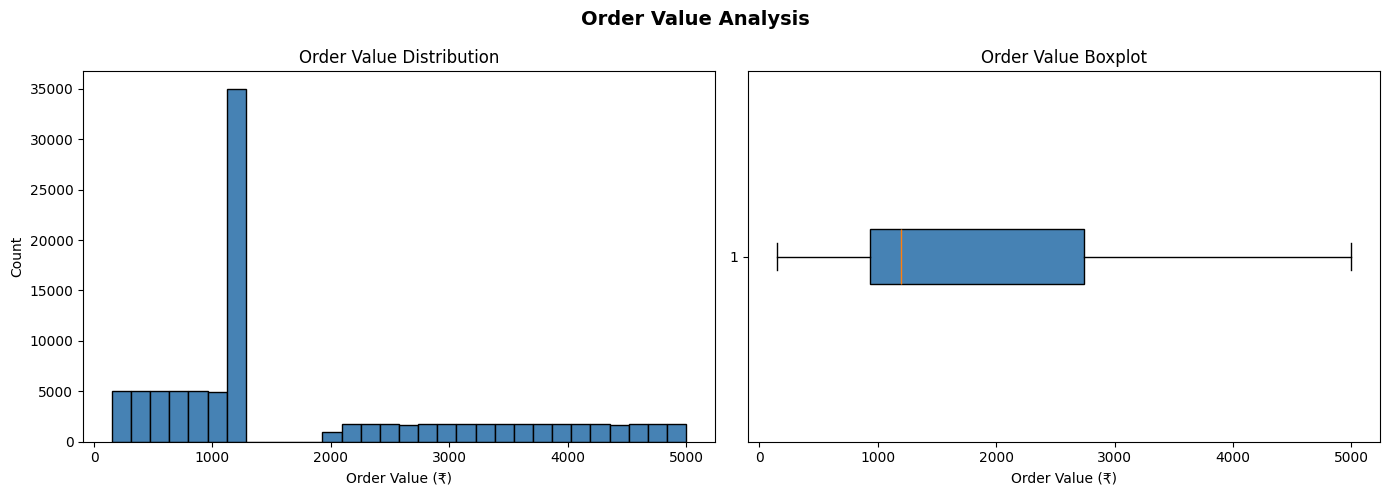

Mean Order Value: ₹ 1786.33
Median Order Value: ₹ 1197.0
Max Order Value: ₹ 5000.0


In [44]:
# ── Chart 1: Order Value Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Order_Value'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Order Value Distribution')
axes[0].set_xlabel('Order Value (₹)')
axes[0].set_ylabel('Count')

# Boxplot
axes[1].boxplot(df['Order_Value'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue'))
axes[1].set_title('Order Value Boxplot')
axes[1].set_xlabel('Order Value (₹)')

plt.suptitle('Order Value Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


print("Mean Order Value: ₹", round(df['Order_Value'].mean(), 2))
print("Median Order Value: ₹", round(df['Order_Value'].median(), 2))
print("Max Order Value: ₹", round(df['Order_Value'].max(), 2))

In [45]:
df['City'].value_counts()

,count
City,
Hyderabad,32738
Bangalore,16324
Delhi,16255
Mumbai,16075
Chennai,16022


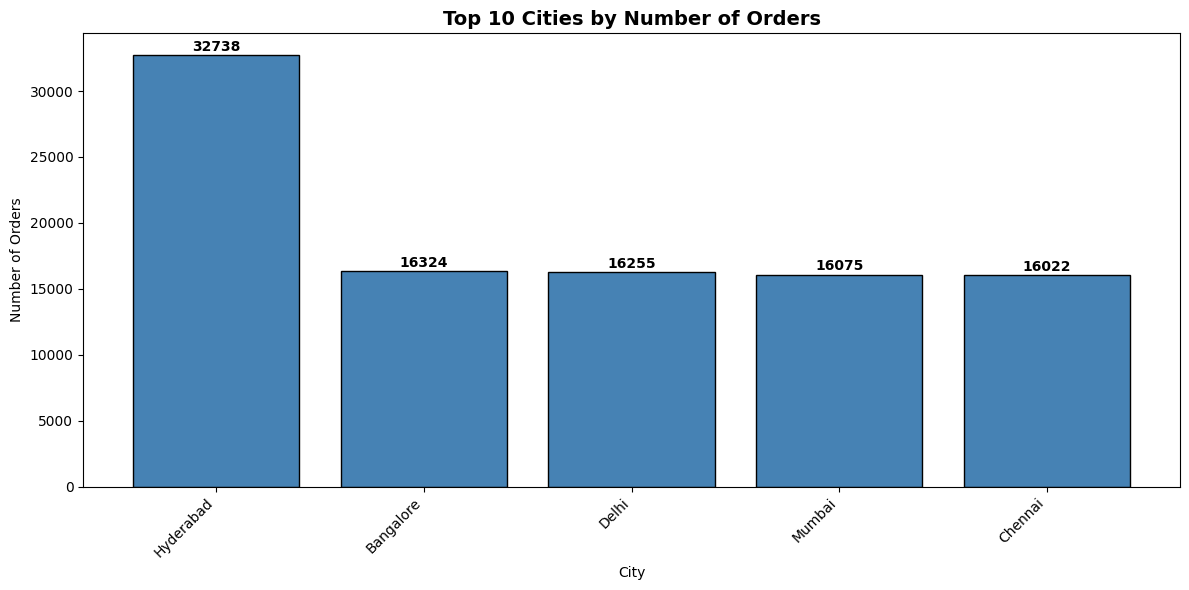

Top 3 cities by orders:
City
Hyderabad    32738
Bangalore    16324
Delhi        16255
Name: count, dtype: int64


In [46]:
# ── Chart 2: Top 10 Cities by Orders ──────────────────────
top_cities = df['City'].value_counts().head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(top_cities.index, top_cities.values, color='steelblue', edgecolor='black')

for bar, val in zip(bars, top_cities.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             str(val), ha='center', va='bottom', fontweight='bold')

plt.title('Top 10 Cities by Number of Orders', fontsize=14, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Business insight
print("Top 3 cities by orders:")
print(top_cities.head(3))

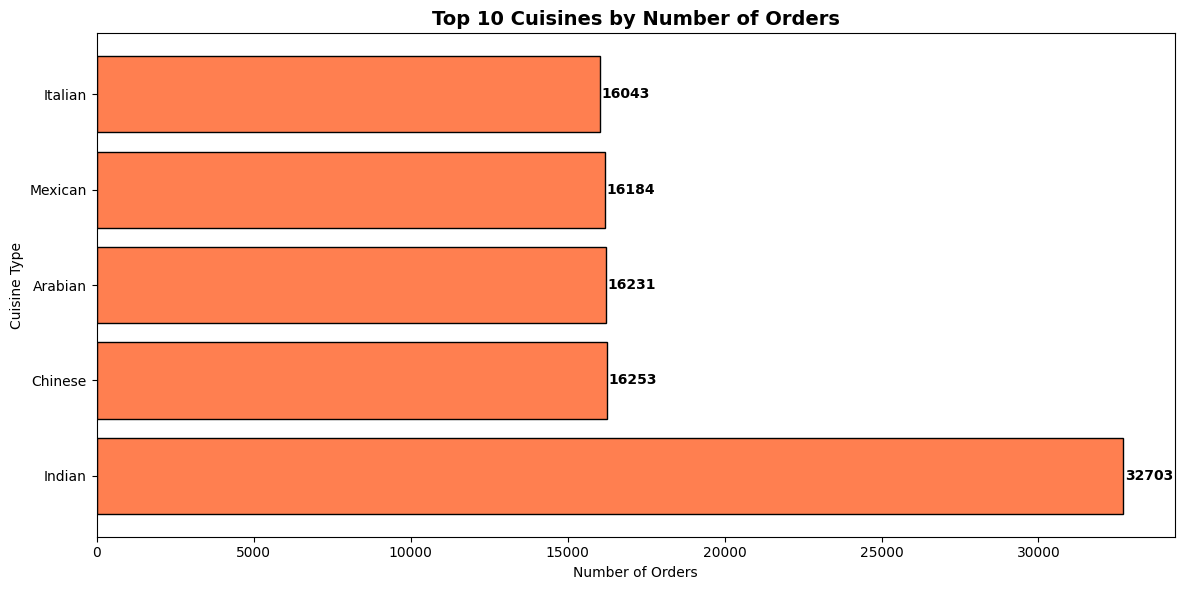

Top 3 cuisines by orders:
Cuisine_Type
Indian     32703
Chinese    16253
Arabian    16231
Name: count, dtype: int64

Avg Order Value by Cuisine:
Cuisine_Type
Indian     1795.641470
Mexican    1791.688581
Chinese    1790.436904
Italian    1775.127158
Arabian    1769.212125
Name: Order_Value, dtype: float64


In [47]:
# ── Chart 3: Cuisine-wise Order Count ─────────────────────
top_cuisines = df['Cuisine_Type'].value_counts().head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(top_cuisines.index, top_cuisines.values,
                color='coral', edgecolor='black')

# Add value labels
for bar, val in zip(bars, top_cuisines.values):
    plt.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             str(val), ha='left', va='center', fontweight='bold')

plt.title('Top 10 Cuisines by Number of Orders', fontsize=14, fontweight='bold')
plt.xlabel('Number of Orders')
plt.ylabel('Cuisine Type')
plt.tight_layout()
plt.show()

# Business insight
print("Top 3 cuisines by orders:")
print(top_cuisines.head(3))
print("\nAvg Order Value by Cuisine:")
print(df.groupby('Cuisine_Type')['Order_Value'].mean().sort_values(ascending=False).head(5))

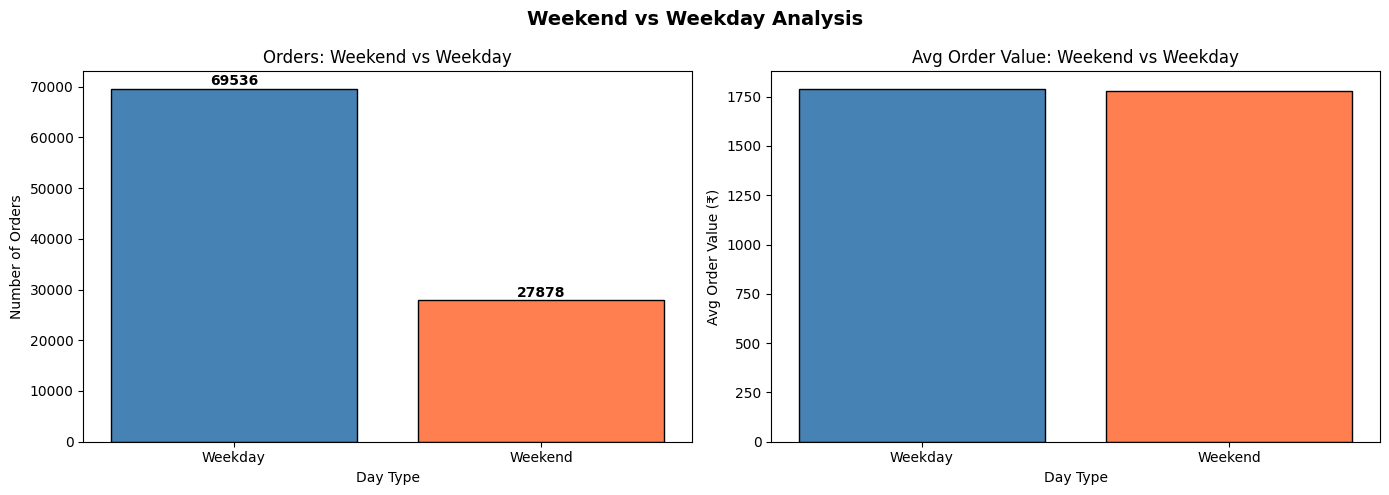

Order counts:
 Weekday    69536
Weekend    27878
Name: count, dtype: int64

Avg Order Value:
 Weekday    1788.950227
Weekend    1779.809384
Name: Order_Value, dtype: float64


In [48]:
# ── Chart 4: Weekend vs Weekday Demand ────────────────────
weekend_counts = df['is_weekend'].value_counts()
weekend_counts.index = ['Weekday', 'Weekend']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(weekend_counts.index, weekend_counts.values,
                   color=['steelblue', 'coral'], edgecolor='black')
for bar, val in zip(bars, weekend_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 str(val), ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Orders: Weekend vs Weekday')
axes[0].set_xlabel('Day Type')
axes[0].set_ylabel('Number of Orders')

# Avg Order Value comparison
avg_order = df.groupby('is_weekend')['Order_Value'].mean()
avg_order.index = ['Weekday', 'Weekend']
axes[1].bar(avg_order.index, avg_order.values,
            color=['steelblue', 'coral'], edgecolor='black')
axes[1].set_title('Avg Order Value: Weekend vs Weekday')
axes[1].set_xlabel('Day Type')
axes[1].set_ylabel('Avg Order Value (₹)')

plt.suptitle('Weekend vs Weekday Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Business insight
print("Order counts:\n", weekend_counts)
print("\nAvg Order Value:\n", avg_order)

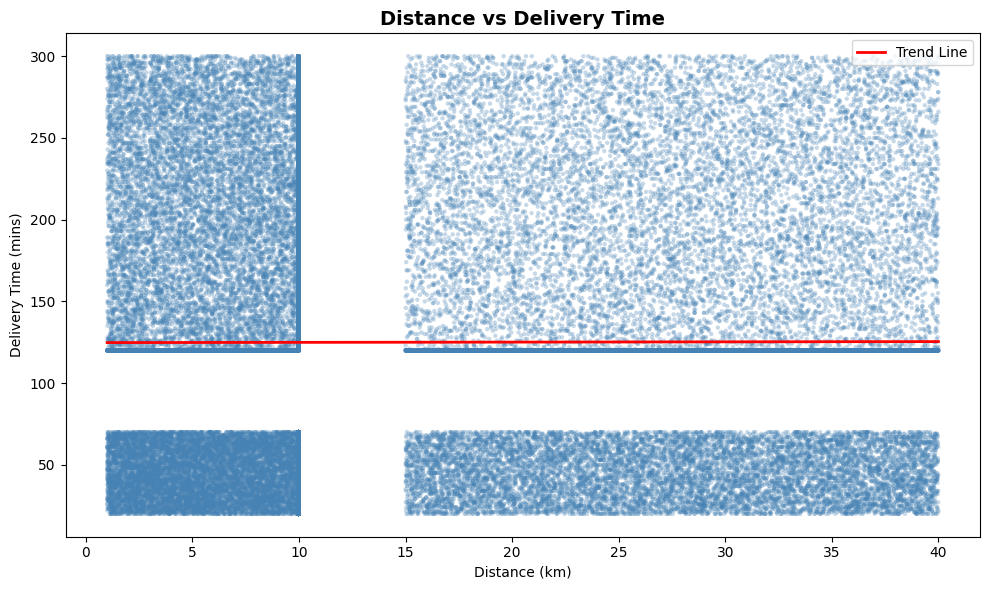

Correlation between Distance and Delivery Time: 0.00
Avg Delivery Time: 125.0 mins
Avg Distance: 14.3 km


In [49]:
# ── Chart 5: Distance vs Delivery Time ────────────────────
plt.figure(figsize=(10, 6))

plt.scatter(df['Distance_km'], df['Delivery_Time_Min'],
            alpha=0.3, color='steelblue', edgecolor='none', s=10)

# Trend line
z = np.polyfit(df['Distance_km'], df['Delivery_Time_Min'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Distance_km'].min(), df['Distance_km'].max(), 100)
plt.plot(x_line, p(x_line), color='red', linewidth=2, label='Trend Line')

plt.title('Distance vs Delivery Time', fontsize=14, fontweight='bold')
plt.xlabel('Distance (km)')
plt.ylabel('Delivery Time (mins)')
plt.legend()
plt.tight_layout()
plt.show()

# Business insight
corr = df['Distance_km'].corr(df['Delivery_Time_Min'])
print(f"Correlation between Distance and Delivery Time: {corr:.2f}")
print(f"Avg Delivery Time: {df['Delivery_Time_Min'].mean():.1f} mins")
print(f"Avg Distance: {df['Distance_km'].mean():.1f} km")

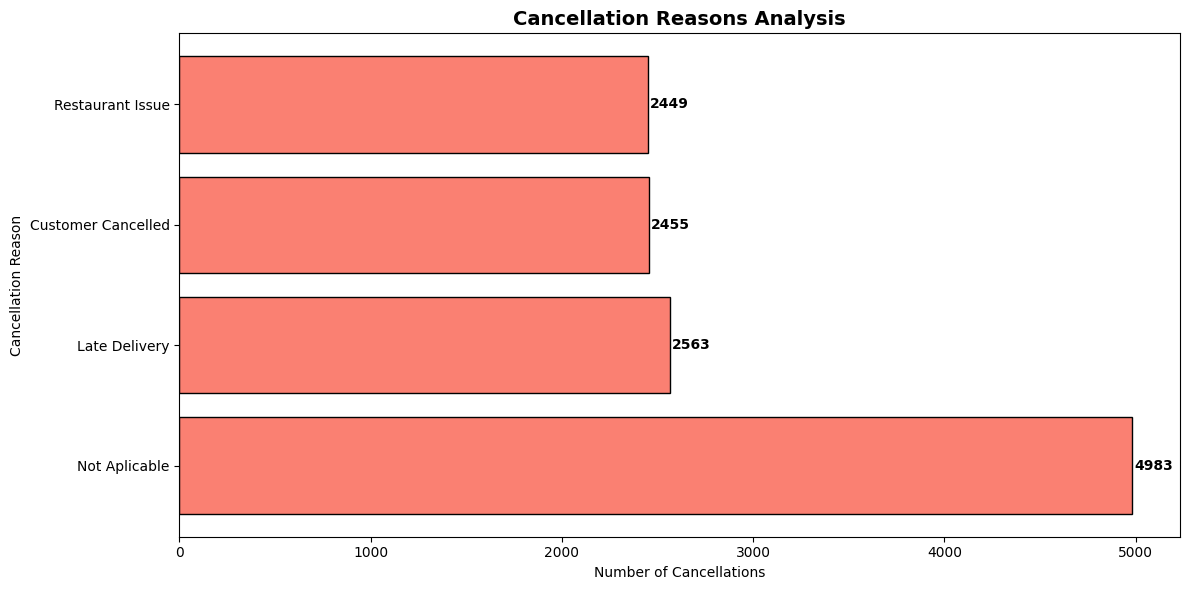

Total Orders: 97414
Total Cancelled: 12450
Cancellation Rate: 12.78%

Top Cancellation Reason: Not Aplicable (4983)


In [52]:
# ── Chart 6: Cancellation Reasons ─────────────────────────
cancel_df = df[df['Order_Status'] == 'Cancelled']
cancel_reasons = cancel_df['Cancellation_Reason'].value_counts()

plt.figure(figsize=(12, 6))
bars = plt.barh(cancel_reasons.index, cancel_reasons.values,
                color='salmon', edgecolor='black')

# Add value labels
for bar, val in zip(bars, cancel_reasons.values):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             str(val), ha='left', va='center', fontweight='bold')

plt.title('Cancellation Reasons Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Number of Cancellations')
plt.ylabel('Cancellation Reason')
plt.tight_layout()
plt.show()

# Business insight
total_orders = len(df)
total_cancelled = len(cancel_df)
cancel_rate = round(total_cancelled / total_orders * 100, 2)

print(f"Total Orders: {total_orders}")
print(f"Total Cancelled: {total_cancelled}")
print(f"Cancellation Rate: {cancel_rate}%")
print(f"\nTop Cancellation Reason: {cancel_reasons.index[0]} ({cancel_reasons.values[0]})")

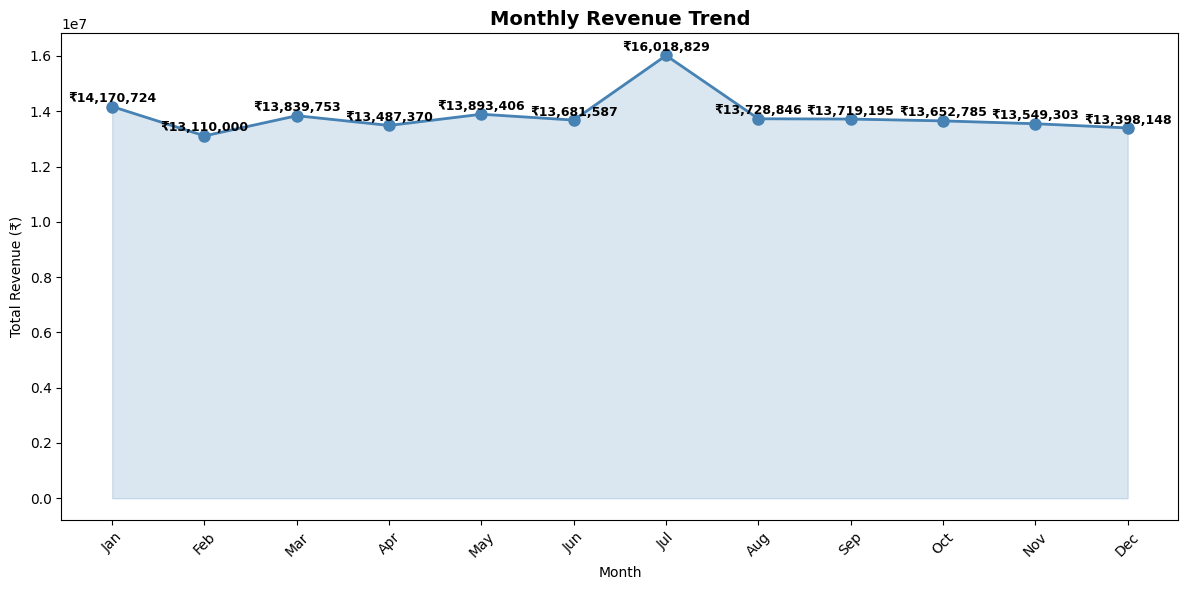

Monthly Revenue Summary:
   Month_Name     Revenue
0         Jan  14170724.0
1         Feb  13110000.0
2         Mar  13839753.0
3         Apr  13487370.0
4         May  13893406.0
5         Jun  13681587.0
6         Jul  16018829.0
7         Aug  13728846.0
8         Sep  13719195.0
9         Oct  13652785.0
10        Nov  13549303.0
11        Dec  13398148.0

Best Month: Jul
Worst Month: Feb


In [53]:
# ── Chart 7: Monthly Revenue Trend ────────────────────────
monthly_revenue = df.groupby('Order_Month')['Final_Amount'].sum().reset_index()
monthly_revenue.columns = ['Month', 'Revenue']

# Month names for x axis
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_revenue['Month_Name'] = monthly_revenue['Month'].apply(lambda x: month_names[x-1])

plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue['Month_Name'], monthly_revenue['Revenue'],
         marker='o', color='steelblue', linewidth=2, markersize=8)

# Add value labels
for i, row in monthly_revenue.iterrows():
    plt.text(i, row['Revenue'] + 50000, f"₹{row['Revenue']:,.0f}",
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.fill_between(monthly_revenue['Month_Name'], monthly_revenue['Revenue'],
                 alpha=0.2, color='steelblue')

plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Business insight
print("Monthly Revenue Summary:")
print(monthly_revenue[['Month_Name','Revenue']])
print(f"\nBest Month: {monthly_revenue.loc[monthly_revenue['Revenue'].idxmax(), 'Month_Name']}")
print(f"Worst Month: {monthly_revenue.loc[monthly_revenue['Revenue'].idxmin(), 'Month_Name']}")

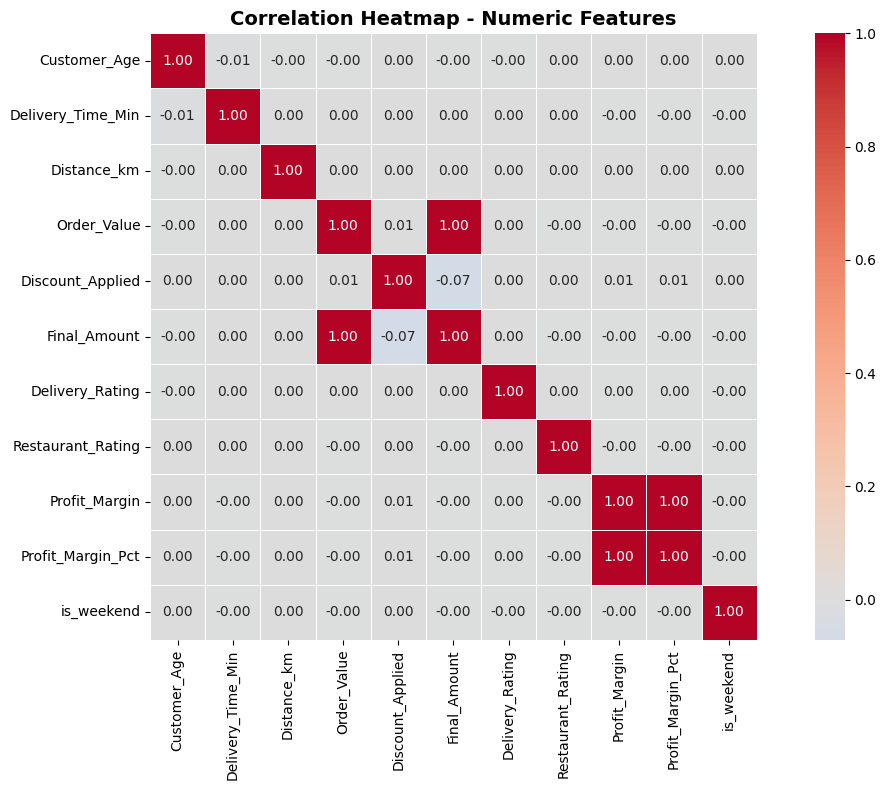

Strong correlations (>0.5 or <-0.5):
Order_Value vs Final_Amount: 1.00
Final_Amount vs Order_Value: 1.00
Profit_Margin vs Profit_Margin_Pct: 1.00
Profit_Margin_Pct vs Profit_Margin: 1.00


In [54]:
# ── Chart 8: Correlation Heatmap ──────────────────────────
num_cols = ['Customer_Age', 'Delivery_Time_Min', 'Distance_km',
            'Order_Value', 'Discount_Applied', 'Final_Amount',
            'Delivery_Rating', 'Restaurant_Rating', 'Profit_Margin',
            'Profit_Margin_Pct', 'is_weekend']

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)

plt.title('Correlation Heatmap - Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Business insight
print("Strong correlations (>0.5 or <-0.5):")
for col1 in num_cols:
    for col2 in num_cols:
        if col1 != col2:
            corr_val = corr_matrix.loc[col1, col2]
            if abs(corr_val) > 0.5:
                print(f"{col1} vs {col2}: {corr_val:.2f}")

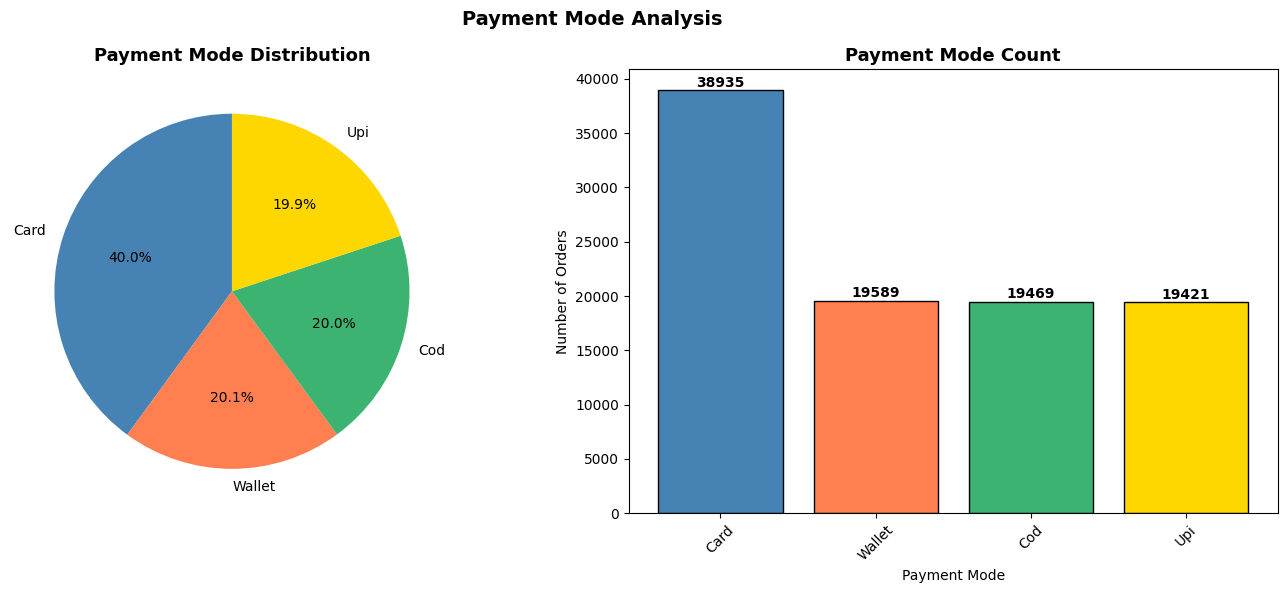

Payment Mode breakdown:
Payment_Mode
Card      38935
Wallet    19589
Cod       19469
Upi       19421
Name: count, dtype: int64

Most preferred: Card (38935 orders)


In [56]:
# ── Chart 9: Payment Mode Preference ──────────────────────
payment_counts = df['Payment_Mode'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
axes[0].pie(payment_counts.values, labels=payment_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=['steelblue','coral','mediumseagreen','gold','mediumpurple'])
axes[0].set_title('Payment Mode Distribution', fontsize=13, fontweight='bold')

# Bar chart
bars = axes[1].bar(payment_counts.index, payment_counts.values,
                   color=['steelblue','coral','mediumseagreen','gold','mediumpurple'],
                   edgecolor='black')
for bar, val in zip(bars, payment_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 str(val), ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Payment Mode Count', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Payment Mode')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Payment Mode Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Business insight
print("Payment Mode breakdown:")
print(payment_counts)
print(f"\nMost preferred: {payment_counts.index[0]} ({payment_counts.values[0]} orders)")

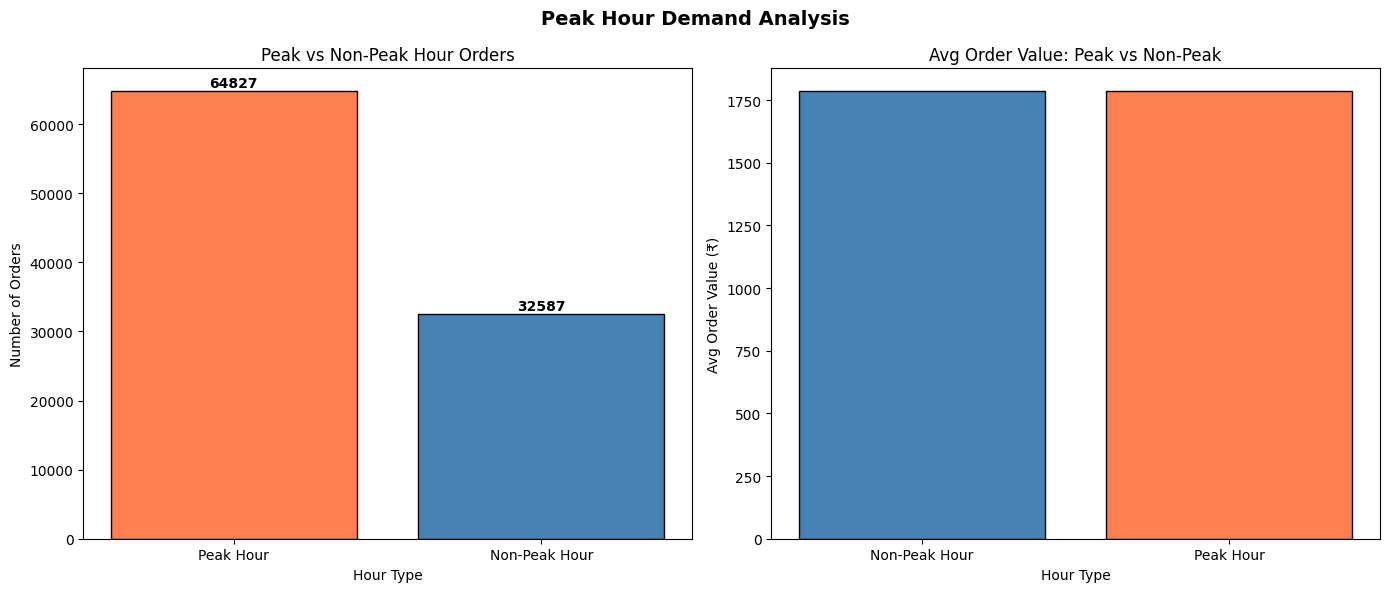

Peak Hour Order counts:
Peak Hour        64827
Non-Peak Hour    32587
Name: count, dtype: int64

Avg Order Value:
Non-Peak Hour    1785.834868
Peak Hour        1787.327830
Name: Order_Value, dtype: float64

% of orders during peak hours: 66.55%


In [57]:
# ── Chart 10: Peak Hour Demand ─────────────────────────────
peak_counts = df['Peak_Hour'].value_counts()
peak_counts.index = ['Peak Hour', 'Non-Peak Hour']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
bars = axes[0].bar(peak_counts.index, peak_counts.values,
                   color=['coral', 'steelblue'], edgecolor='black')
for bar, val in zip(bars, peak_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 str(val), ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Peak vs Non-Peak Hour Orders')
axes[0].set_xlabel('Hour Type')
axes[0].set_ylabel('Number of Orders')

# Avg order value during peak vs non-peak
avg_val = df.groupby('Peak_Hour')['Order_Value'].mean()
avg_val.index = ['Non-Peak Hour', 'Peak Hour']
axes[1].bar(avg_val.index, avg_val.values,
            color=['steelblue', 'coral'], edgecolor='black')
axes[1].set_title('Avg Order Value: Peak vs Non-Peak')
axes[1].set_xlabel('Hour Type')
axes[1].set_ylabel('Avg Order Value (₹)')

plt.suptitle('Peak Hour Demand Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Business insight
print("Peak Hour Order counts:")
print(peak_counts)
print(f"\nAvg Order Value:\n{avg_val}")
peak_pct = round(peak_counts['Peak Hour'] / len(df) * 100, 2)
print(f"\n% of orders during peak hours: {peak_pct}%")

In [58]:
from google.colab import files
files.download('food_delivery_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>